# L3 — Trend Long-Horizon (LSTM directionnel) sur le panier anti-biais

> **Ladder ML #1409** | [L1 TSMOM](research_l1_tsmom.ipynb) · [L2 CS+DM](research_l2_dual_momentum.ipynb) · **L3 Trend Long-Horizon** · [L4 Decision Transformer](research_l4_decision_transformer.ipynb)

Troisième échelon du curriculum ML trading V3 (Epic #1409). Après L1/L2 (baselines
**non-ML** de momentum), L3 est le **premier échelon ML** : un LSTM entraîné sur GPU à
prédire la **direction** des rendements à long horizon ($h \in \{60, 120, 252\}$ jours),
walk-forward 5 folds × 4 seeds, sur le panier anti-biais (25 symboles, sans FAANG/Mag7).

Ce notebook **interprète les résultats canoniques du sweep GPU** (300 combinaisons :
25 symboles × 3 horizons × 4 seeds), produits par `scripts/L3_trend_long_horizon_gpu.py`
sur GPU 2 et **committés** dans `scripts/results/l3_trend_long_horizon/`. On y reproduit
fidèlement le verdict **NO BEATS** (#1576) sans ré-entraîner le modèle (pas de GPU requis).

### Verdict de référence (#1576)

**NO BEATS** : aucun combo ne passe le gate d'edge (max sigma_edge = 1.49 < 2.0 requis).
Le LSTM ne distingue pas la direction des rendements long-horizon — l'AUC médian est
**0.509 ≡ chance pure**, et la précision directionnelle **perd contre la baseline
majority** (le LSTM fait pire que « toujours prédire la classe majoritaire »). C'est le
verdict canonique : la prédiction de direction long-horizon **échoue** sur le panier
anti-biais, là même où L1/L2 (momentum) rataient déjà le B&H.

### Implication pour le ladder

L1 (TSMOM) et L2 (CS+DM) : momentum NO BEATS (le signal existe mais les coûts / le B&H
dominent). L3 (LSTM directionnel) : **ML de prévision de direction aussi NO BEATS**. C'est
le constat qui motive **L4 Decision Transformer** : changer de paradigme — au lieu de
prévoir un *retour* (L3) ou un *signe de momentum* (L1/L2), apprendre directement une
*action* (buy/hold/sell) par offline RL. **L4 est le seul BEATS du ladder** (#1461).

## 1. Chargement des résultats canoniques du sweep GPU

Le sweep (300 combos, ~15 min sur GPU 2) est committé :
- `results.json` : verdict agrégé + 75 cellules (symbol × horizon) avec `sigma_edge`.
- `checkpoint.jsonl` : 300 lignes (25 symboles × 3 horizons × 4 seeds) avec AUC, dir_acc,
  majority, sharpe, sharpe_bh. **Ce sont les vraies sorties du run** (`device: cuda`,
  `smoke: false`).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

RESULTS_DIR = Path("scripts/results/l3_trend_long_horizon")
summary = json.loads((RESULTS_DIR / "results.json").read_text())
rows = [json.loads(line) for line in (RESULTS_DIR / "checkpoint.jsonl").read_text().strip().split("\n")]
df = pd.DataFrame(rows)

print(f"Verdict canonique : {summary['verdict']}")
print(f"n_signal : {summary['n_signal']} / {summary['n_cells']} cellules "
      f"(combo avec edge >= 2 sigma)")
print(f"AUC median : {summary['median_auc']:.4f}  (0.5 = hasard)")
print(f"n_combos : {summary['n_combos']} | device : {summary['device']} | "
      f"smoke : {summary['smoke']} (run reel)")
print(f"\nCheckpoint : {len(df)} lignes combo | horizons : {sorted(df.horizon.unique())} "
      f"| seeds : {sorted(df.seed.unique())}")
print(f"Symboles ({df.symbol.nunique()}) : {', '.join(sorted(df.symbol.unique())[:8])} ...")
df.head(3)

Verdict canonique : NO BEATS
n_signal : 0 / 75 cellules (combo avec edge >= 2 sigma)
AUC median : 0.5088  (0.5 = hasard)
n_combos : 300 | device : cuda | smoke : False (run reel)

Checkpoint : 300 lignes combo | horizons : [np.int64(60), np.int64(120), np.int64(252)] | seeds : [np.int64(0), np.int64(1), np.int64(7), np.int64(42)]
Symboles (25) : BTC-USD, DBA, EEM, EFA, ETH-USD, GLD, IEF, IWM ...


,symbol,horizon,seed,auc,dir_acc,majority,sharpe,sharpe_bh,delta_sharpe,n_obs
0,SPY,252,0,0.497197,0.481944,0.512037,0.692906,0.873057,-0.180151,2160
1,SPY,252,1,0.541853,0.493519,0.512037,0.582789,0.873057,-0.290269,2160
2,SPY,252,7,0.478332,0.486111,0.512037,0.259828,0.873057,-0.613230,2160


## 2. Le verdict NO BEATS : le gate d'edge

Le gate exige un **edge ≥ 2σ cross-seed** (`EDGE_SIGMA = 2.0`) pour déclarer un combo
« signal ». Sur les 75 cellules (symbol × horizon), **zéro** ne passe le gate : le
`sigma_edge` maximum observé est **1.49**, en dessous du seuil. La prédiction de direction
n'est pas statistiquement exploitable.

In [2]:
print(f"Gate : edge >= 2.0 sigma requis pour 'signal'")
print(f"Cellules 'signal' (is_signal=True) : "
      f"{sum(1 for e in summary['edges'] if e.get('is_signal'))} / {summary['n_cells']}")
print(f"sigma_edge max observe : {max(e['sigma_edge'] for e in summary['edges']):.3f}")
print(f"sigma_edge median : "
      f"{float(np.median([e['sigma_edge'] for e in summary['edges']])):.3f}")

sigma_edges = np.array([e["sigma_edge"] for e in summary["edges"]])
print(f"\nDistribution sigma_edge (75 cellules) :")
print(f"  min {sigma_edges.min():.2f} | Q25 {np.percentile(sigma_edges,25):.2f} | "
      f"median {np.median(sigma_edges):.2f} | Q75 {np.percentile(sigma_edges,75):.2f} | "
      f"max {sigma_edges.max():.2f}")
print(f"\nVerdict : {summary['verdict']} (0 signal / {summary['n_cells']} cellules).")

Gate : edge >= 2.0 sigma requis pour 'signal'
Cellules 'signal' (is_signal=True) : 0 / 75
sigma_edge max observe : 1.493
sigma_edge median : -3.264

Distribution sigma_edge (75 cellules) :
  min -24.33 | Q25 -5.18 | median -3.26 | Q75 -1.80 | max 1.49

Verdict : NO BEATS (0 signal / 75 cellules).


## 3. Pourquoi NO BEATS : AUC ≡ hasard

L'AUC (area under ROC) mesure la capacité du LSTM à séparer rendements positifs vs
négatifs. **0.5 = pile-ou-face**. Sur 300 combos, l'AUC médian est **0.509** et l'AUC
moyen **0.508** : le LSTM n'apprend **rien** de prédictible à long horizon. Seulement
64.7 % des combos dépassent 0.5 — à peine mieux que le hasard.

AUC : median 0.5088 | mean 0.5076 | min 0.443 | max 0.576
Combos AUC > 0.5 : 64.7%  (le hasard donnerait ~50%)
Combos AUC > 0.55 : 2.0%  (signal faible)


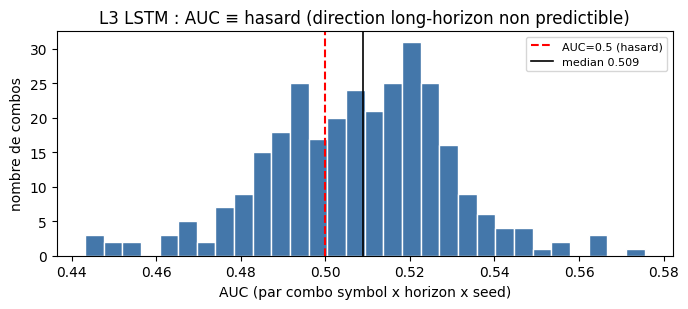

In [3]:
print(f"AUC : median {df.auc.median():.4f} | mean {df.auc.mean():.4f} | "
      f"min {df.auc.min():.3f} | max {df.auc.max():.3f}")
print(f"Combos AUC > 0.5 : {(df.auc > 0.5).mean():.1%}  (le hasard donnerait ~50%)")
print(f"Combos AUC > 0.55 : {(df.auc > 0.55).mean():.1%}  (signal faible)")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(df.auc, bins=30, color="#4477aa", edgecolor="white")
ax.axvline(0.5, color="red", linestyle="--", linewidth=1.5, label="AUC=0.5 (hasard)")
ax.axvline(df.auc.median(), color="black", linestyle="-", linewidth=1.2,
           label=f"median {df.auc.median():.3f}")
ax.set_xlabel("AUC (par combo symbol x horizon x seed)")
ax.set_ylabel("nombre de combos")
ax.set_title("L3 LSTM : AUC ≡ hasard (direction long-horizon non predictible)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

## 4. Pire que la baseline majority

Plus révélateur encore : la précision directionnelle du LSTM **perd contre la baseline
majority** (« toujours prédire la classe majoritaire »). En théorie, un modèle ML doit au
minimum battre cette baseline triviale. Ici, le LSTM ne le fait que dans **24 %** des
combos.

dir_acc LSTM  : median 0.5052 | mean 0.5046
majority base : median 0.5208 | mean 0.5220
Combos ou LSTM > majority : 24.0%
  (un modele utile devrait battre majority dans la majorite des cas)


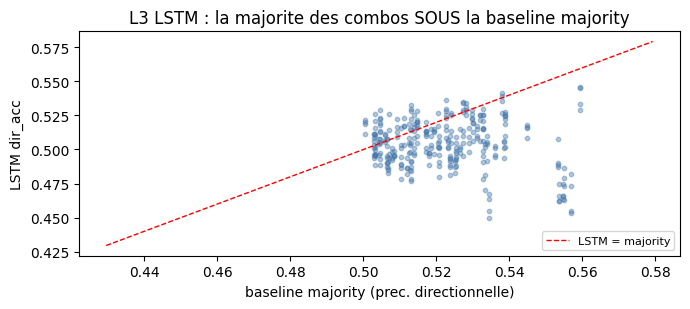

In [4]:
print(f"dir_acc LSTM  : median {df.dir_acc.median():.4f} | mean {df.dir_acc.mean():.4f}")
print(f"majority base : median {df.majority.median():.4f} | mean {df.majority.mean():.4f}")
print(f"Combos ou LSTM > majority : {(df.dir_acc > df.majority).mean():.1%}")
print(f"  (un modele utile devrait battre majority dans la majorite des cas)")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.scatter(df.majority, df.dir_acc, s=10, alpha=0.4, color="#4477aa")
lims = [min(df.majority.min(), df.dir_acc.min()) - 0.02,
        max(df.majority.max(), df.dir_acc.max()) + 0.02]
ax.plot(lims, lims, color="red", linestyle="--", linewidth=1, label="LSTM = majority")
ax.set_xlabel("baseline majority (prec. directionnelle)")
ax.set_ylabel("LSTM dir_acc")
ax.set_title("L3 LSTM : la majorite des combos SOUS la baseline majority")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

## 5. Impact trading : Sharpe delta vs buy-and-hold

Au final, ce qui compte est le **delta de Sharpe** (stratégie LSTM − buy-and-hold). Sur
300 combos, le delta médian est **−0.51** et seul **8.7 %** des combos ont un delta positif.
Tous horizons confondus, le LSTM sous-performe le B&H.

In [5]:
print(f"delta_sharpe : median {df.delta_sharpe.median():.4f} | "
      f"mean {df.delta_sharpe.mean():.4f}")
print(f"Combos delta_sharpe > 0 : {(df.delta_sharpe > 0).mean():.1%}")
print(f"\nPar horizon (moyenne sur les combos) :")
for h in sorted(df.horizon.unique()):
    sub = df[df.horizon == h]
    print(f"  h={h:>3}j | n={len(sub):>3} | mean delta_sharpe {sub.delta_sharpe.mean():+.4f} "
          f"| mean AUC {sub.auc.mean():.4f} | frac delta>0 {(sub.delta_sharpe>0).mean():.0%}")

delta_sharpe : median -0.5093 | mean -0.5053
Combos delta_sharpe > 0 : 8.7%

Par horizon (moyenne sur les combos) :
  h= 60j | n=100 | mean delta_sharpe -0.4408 | mean AUC 0.5025 | frac delta>0 8%
  h=120j | n=100 | mean delta_sharpe -0.5740 | mean AUC 0.5110 | frac delta>0 5%
  h=252j | n=100 | mean delta_sharpe -0.5011 | mean AUC 0.5091 | frac delta>0 13%


### Meilleures et pires cellules (delta_sharpe moyen sur les seeds)

Même les meilleures cellules (TLT, ETH-USD, DBA à h=252) restent marginales, et les pires
(SHY/XLB/RSP) montrent que la prédiction directionnelle **échoue surtout sur les
obligations** et les ETFs à faible trend.

In [6]:
agg = df.groupby(["symbol", "horizon"]).delta_sharpe.mean().sort_values()
print("=== 5 PIREES cellules (delta_sharpe le plus negatif) ===")
print(agg.head(5).round(3).to_string())
print("\n=== 5 MEILLEURES cellules ===")
print(agg.tail(5).round(3).to_string())
print(f"\nSur 75 cellules : {(agg > 0).sum()} positives, {(agg <= 0).sum()} negatives.")

=== 5 PIREES cellules (delta_sharpe le plus negatif) ===
symbol   horizon
SHY      252       -2.140
XLB      120       -1.305
RSP      120       -1.086
ETH-USD  60        -1.076
XLB      252       -1.057

=== 5 MEILLEURES cellules ===
symbol   horizon
IEF      252        0.000
XLY      60         0.053
DBA      252        0.058
ETH-USD  252        0.225
TLT      252        0.384

Sur 75 cellules : 5 positives, 70 negatives.


## 6. Exercices

Les exercices sont à compléter. Les stubs s'exécutent sans erreur (ils retournent `None`).

### Exercice 1 — L'effet de l'horizon

**Contexte** : L3 sweep les horizons 60/120/252j. On s'attendrait à ce que les horizons
longs soient *plus prévisibles* (plus de signal trend).

**Objectif** : à partir de `df`, calculez pour chaque horizon l'AUC moyen et la part de
combos avec `delta_sharpe > 0`. L'hypothèse « horizon long = plus prévisible » se
vérifie-t-elle sur le AUC ? sur le Sharpe ?

*Indice* : `df.groupby('horizon')` puis `.agg(...)` sur `auc` et une lambda sur
`delta_sharpe > 0`.

In [7]:
def horizon_analysis(df):
    # Retourne un DataFrame indexe par horizon avec colonnes mean_auc, mean_delta_sharpe,
    # frac_delta_positive.
    # TODO etudiant : groupby horizon, agreger auc / delta_sharpe
    result = None  # TODO etudiant
    return result

ha = horizon_analysis(df)
if ha is not None:
    print(ha)

### Exercice 2 — LSTMs vs majority baseline par classe d'actifs

**Contexte** : le LSTM perd contre majority dans 76 % des combos. Mais cela dépend
peut-être de la classe d'actifs (crypto plus bruitée ? obligations plus prévisibles ?).

**Objectif** : étiquetez chaque combo par classe d'actifs (via `PANIER_GROUPS`), puis
calculez le taux « LSTM > majority » par classe. Quelle classe « résiste » le mieux ?

*Indice* : construisez un mapping symbol → groupe (un symbole appartient à un seul groupe),
ajoutez une colonne `group` à `df`, puis `df.groupby('group').apply(...)`.

In [8]:
def lstm_vs_majority_by_class(df, panier_groups):
    # Retourne {group: fraction de combos ou dir_acc > majority}.
    # TODO etudiant : mapper symbol -> groupe, groupby, calculer le taux
    result = None  # TODO etudiant
    return result

import sys
sys.path.insert(0, str(Path("scripts").resolve()))
from panier_loader import PANIER_GROUPS
class_res = lstm_vs_majority_by_class(df, PANIER_GROUPS)
if class_res is not None:
    for g, frac in sorted(class_res.items(), key=lambda x: -x[1]):
        print(f"{g:<22} LSTM > majority : {frac:.0%}")

### Exercice 3 — Pourquoi L4 (Decision Transformer) réussit là où L3 échoue

**Contexte** : L3 (prévision de *direction/retour*) = NO BEATS. L4 (Decision Transformer,
*offline RL apprenant une action buy/hold/sell*) = le seul BEATS du ladder (#1461).

**Objectif** : discutez (markdown, pas de code) pourquoi un modèle qui apprend directement
une **action** peut battre un modèle qui prévoit un **retour**. Appuyez-vous sur :
(a) la perte de classification d'action vs la perte de régression de retour, (b) le fait
qu'une mauvaise prévision de retour n'implique pas une mauvaise action (ex: le modèle peut
mal prévoir l'amplitude mais bien le signe de la position optimale), (c) le coût de
transaction (L4 peut apprendre à *ne pas trader* quand le signal est faible).

*Indice* : écrivez 4-6 lignes d'analyse dans une nouvelle cellule markdown.

In [9]:
# Exercice 3 (analyse, pas de code) -- ecrivez votre reponse dans une cellule
# markdown ci-dessous. Ce stub est vide a dessein (pas de calcul attendu).
pass

## Conclusion

| Idée clé | Traduction |
|---|---|
| L3 = 1er échelon ML du ladder | LSTM entraîné à prédire la direction long-horizon (h=60/120/252j) |
| NO BEATS : 0/75 cellules signal | max sigma_edge 1.49 < 2.0 requis, aucun combo exploitable |
| AUC ≡ hasard (0.509) | le LSTM n'apprend rien de prédictible à long horizon |
| Pire que la baseline majority | le LSTM ne bat même pas « toujours prédire la classe majoritaire » |
| delta Sharpe −0.51 médian | 8.7 % des combos seulement battent le B&H |
| Échec surtout sur obligations | SHY/XLB/RSP = pires cellules (actifs à faible trend) |
| Implication ladder | L4 Decision Transformer (action-based offline RL) contourne l'échec de la prévision de retour = seul BEATS |

**Lien avec le ladder** : L1 (momentum temporel) et L2 (momentum cross-sectionnelle) sont
NO BEATS à cause des **coûts / B&H dominant**. L3 (ML directionnel) est NO BEATS à cause de
l'**imprédictibilité directionnelle**. Trois échecs distincts convergent vers le même
constat : prédire un *retour* ou un *signe* ne suffit pas. C'est ce qui motive **L4
Decision Transformer** : apprendre directement la **bonne action** (offline RL), le seul
échelon qui BEATS le buy-and-hold (#1461).

Référence : sweep GPU canonique `scripts/L3_trend_long_horizon_gpu.py` (#1576/#1417),
résultats committés `scripts/results/l3_trend_long_horizon/`. Epic #1409.